=== ZND reference for PDE verification ===
D_CJ                       = 6.415008470922
reaction length (10%-90%) = 40.70515646
reaction length (5%-95%)  = 55.90595739
s(lam=0.5)                = 13.84532009
s(lam=0.9)                = 43.20641311
q_end/c_end               = 0.999996709958

=== PDE verification diagnostics ===
Domain                     = [-20.00, 120.00]
N                          = 1600
final_time                 = 10.000000
cfl                        = 0.200000
react_cfl                  = 0.200000
solver                     = HLLC+MUSCL

Errors vs ZND reference
p   L1(full)               = 2.07019890e+00
p   L1(smooth)             = 2.06780964e+00
rho L1(full)               = 2.55215224e-01
rho L1(smooth)             = 2.55132356e-01
u   L1(full)               = 1.88744860e-01
u   L1(smooth)             = 1.88553502e-01
lam L1(full)               = 7.75559039e-02
lam L1(smooth)             = 7.74445869e-02

Drift from initial ZND profile
p   Linf drift             =

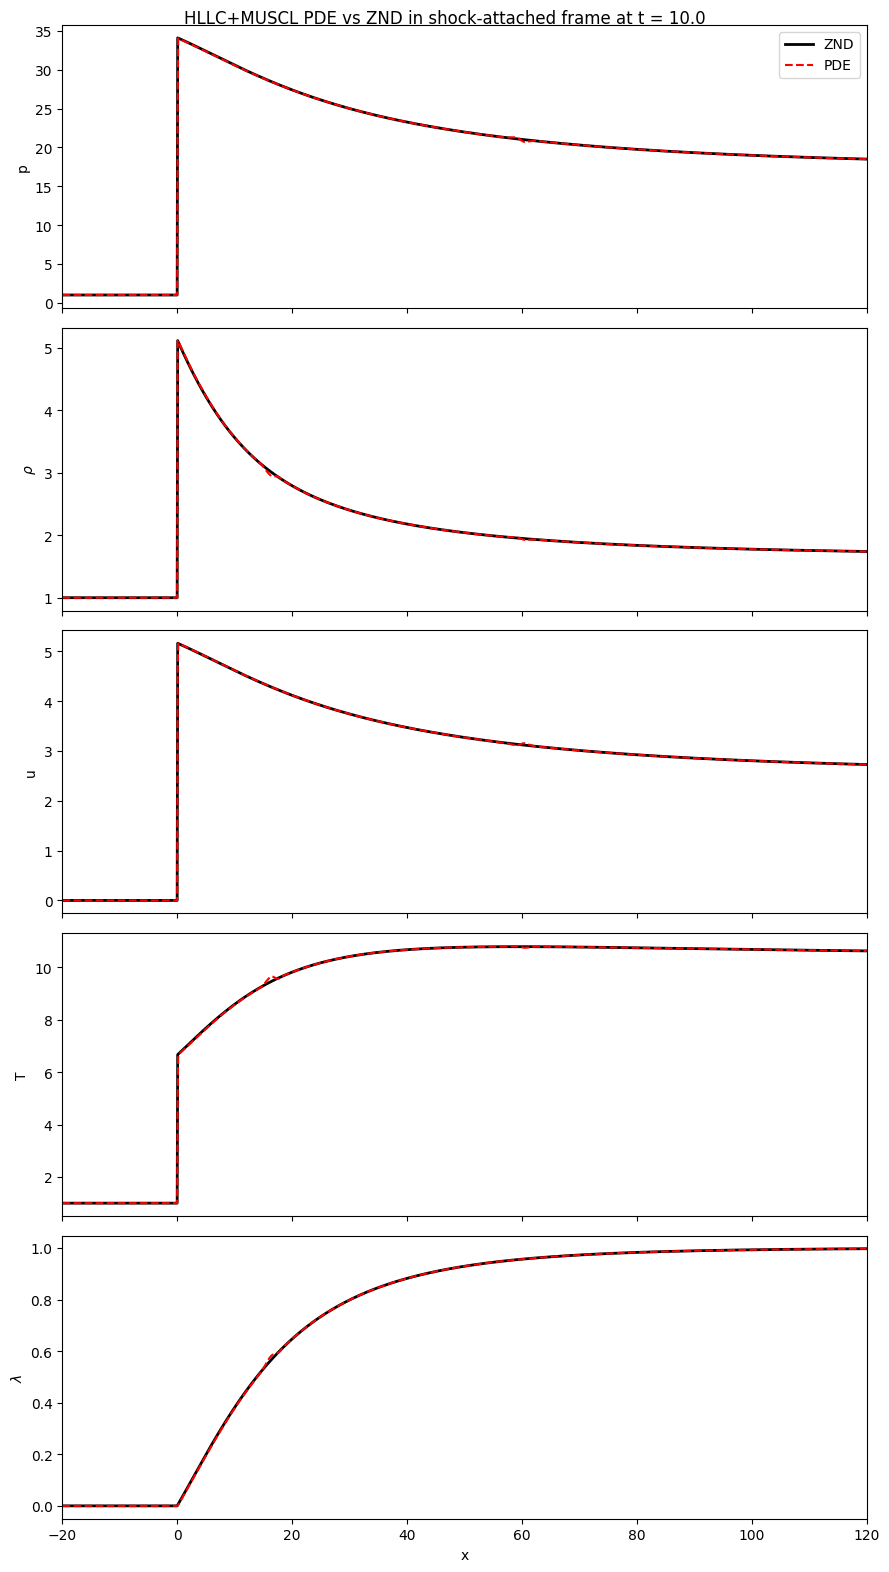

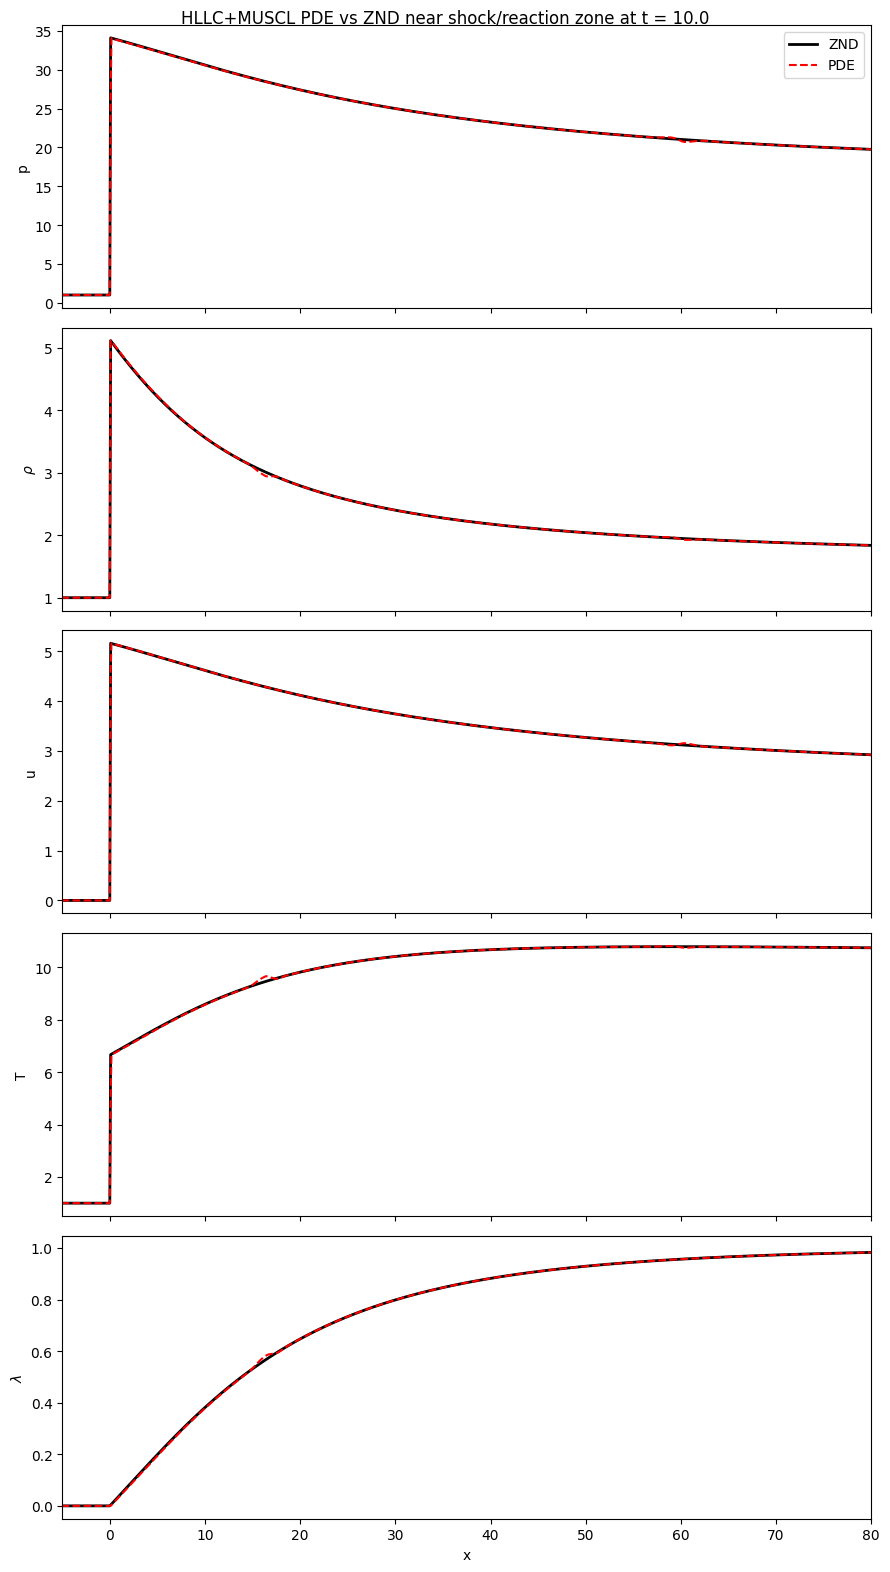

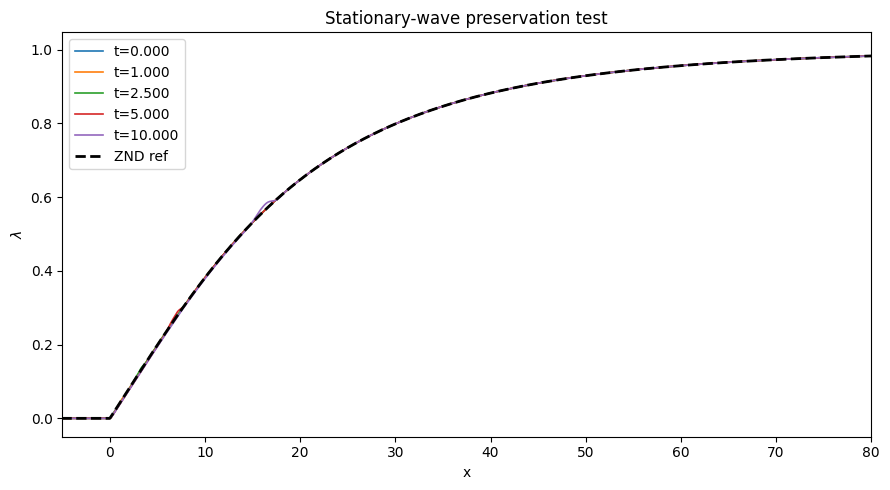


=== Verification grid study against ZND (HLLC+MUSCL, full domain) ===
--------------------------------------------------------------------------------------------------------------------------------------------------
       N           dx     p_L1(full)     p_L1(smooth)   lam_L1(full)   lam_L1(smooth)    p_drift(Linf)    lam_drift(Linf)
--------------------------------------------------------------------------------------------------------------------------------------------------
     400 3.500000e-01   6.342776e+00     3.571587e+00   1.211839e-01     1.207371e-01     7.899151e+00       3.785606e-02
     800 1.750000e-01   4.224827e+00     2.052853e+00   8.945290e-02     8.917315e-02     1.239027e+01       2.166490e-02
    1600 8.750000e-02   2.070200e+00     2.067810e+00   7.755596e-02     7.744463e-02     8.347357e+00       1.531286e-02
    3200 4.375000e-02   8.841265e-01     5.704596e-01   1.727777e-02     1.718770e-02     7.127774e+00       1.801183e-02
-------------------------

In [ ]:
#MODERN SOLVER DEPENDENT ZND
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import math



# ZND reference solver


class ZNDFailure(Exception):
    def __init__(self, lam_fail, last_state=None, message="ZND profile terminated before lam_end"):
        super().__init__(message)
        self.lam_fail = lam_fail
        self.last_state = last_state


@dataclass
class Params:
    gamma: float = 1.4
    Q: float = 20.0
    k: float = 1.0
    Ea: float = 20.0
    R: float = 1.0

    rho_a: float = 1.0
    u_a: float = 0.0
    p_a: float = 1.0
    lam_a: float = 0.0

    n_lam: int = 4000
    lam_end: float = 1.0 - 1.0e-6

    D_bracket_low: float = 1.3
    D_bracket_high: float = 7.0
    cj_tol: float = 1.0e-10
    cj_max_iter: int = 80


def reaction_rate_znd(lam, T, p: Params):
    return p.k * (1.0 - lam) * np.exp(-p.Ea / (p.R * T))


def shock_jump(par: Params, D):
    c_a = math.sqrt(par.gamma * par.p_a / par.rho_a)
    q_a = D - par.u_a
    if q_a <= c_a:
        raise ValueError("D is too small: upstream state is not supersonic relative to the shock.")

    M_a = q_a / c_a

    rho_n = par.rho_a * ((par.gamma + 1.0) * M_a**2) / ((par.gamma - 1.0) * M_a**2 + 2.0)
    p_n = par.p_a * (1.0 + 2.0 * par.gamma / (par.gamma + 1.0) * (M_a**2 - 1.0))
    q_n = q_a * par.rho_a / rho_n
    u_n = D - q_n
    lam_n = par.lam_a

    m = rho_n * q_n
    P = p_n + rho_n * q_n**2
    B = par.gamma / (par.gamma - 1.0) * (p_n / rho_n) - par.Q * lam_n + 0.5 * q_n**2

    T_n = p_n / (rho_n * par.R)
    c_n = math.sqrt(par.gamma * p_n / rho_n)

    vn = {
        "rho": rho_n,
        "u": u_n,
        "q": q_n,
        "p": p_n,
        "T": T_n,
        "c": c_n,
        "lam": lam_n,
    }
    inv = {"m": m, "P": P, "B": B}
    return vn, inv


def state_from_lambda(lam, inv, par: Params, D, v_prev):
    m = inv["m"]
    P = inv["P"]
    B = inv["B"]

    a = m**2 * (par.gamma + 1.0) / (2.0 * (par.gamma - 1.0))
    b = -par.gamma * P / (par.gamma - 1.0)
    c = B + par.Q * lam

    disc = b**2 - 4.0 * a * c
    if disc < 0.0:
        raise ZNDFailure(lam_fail=lam, last_state=None)

    sqrt_disc = math.sqrt(disc)
    roots = [(-b - sqrt_disc) / (2.0 * a), (-b + sqrt_disc) / (2.0 * a)]

    candidates = []
    for v in roots:
        if v <= 0.0:
            continue
        rho = 1.0 / v
        q = m * v
        p = P - m**2 * v
        if rho > 0.0 and q > 0.0 and p > 0.0:
            candidates.append(v)

    if not candidates:
        raise ZNDFailure(lam_fail=lam, last_state=None)

    v = min(candidates, key=lambda x: abs(x - v_prev))

    rho = 1.0 / v
    q = m * v
    u = D - q
    p = P - m**2 * v
    T = p / (rho * par.R)
    c = math.sqrt(par.gamma * p / rho)
    M_rel = q / c
    omega = reaction_rate_znd(lam, T, par)

    return {
        "rho": rho,
        "u": u,
        "q": q,
        "p": p,
        "T": T,
        "c": c,
        "M_rel": M_rel,
        "omega": omega,
        "v": v,
    }


def build_znd_profile(par: Params, D):
    vn, inv = shock_jump(par, D)

    lam = np.linspace(par.lam_a, par.lam_end, par.n_lam)

    rho = np.empty_like(lam)
    u = np.empty_like(lam)
    q = np.empty_like(lam)
    p = np.empty_like(lam)
    T = np.empty_like(lam)
    c = np.empty_like(lam)
    M_rel = np.empty_like(lam)
    omega = np.empty_like(lam)
    s = np.empty_like(lam)

    v_prev = 1.0 / vn["rho"]
    last_state = None

    for i, lam_i in enumerate(lam):
        try:
            st = state_from_lambda(lam_i, inv, par, D, v_prev)
        except ZNDFailure:
            raise ZNDFailure(lam_fail=lam_i, last_state=last_state)

        v_prev = st["v"]
        last_state = st

        rho[i] = st["rho"]
        u[i] = st["u"]
        q[i] = st["q"]
        p[i] = st["p"]
        T[i] = st["T"]
        c[i] = st["c"]
        M_rel[i] = st["M_rel"]
        omega[i] = st["omega"]

    ds_dlam = q / omega
    s[0] = 0.0
    for i in range(1, len(lam)):
        dlam = lam[i] - lam[i - 1]
        s[i] = s[i - 1] + 0.5 * (ds_dlam[i] + ds_dlam[i - 1]) * dlam

    m_prof = rho * q
    P_prof = p + rho * q**2
    B_prof = par.gamma / (par.gamma - 1.0) * (p / rho) - par.Q * lam + 0.5 * q**2

    s_lam_05 = np.interp(0.5, lam, s)
    s_lam_09 = np.interp(0.9, lam, s)
    s_lam_095 = np.interp(0.95, lam, s)
    s_lam_005 = np.interp(0.05, lam, s)

    out = {
        "D": D,
        "s": s,
        "lam": lam,
        "rho": rho,
        "u": u,
        "q": q,
        "p": p,
        "T": T,
        "c": c,
        "M_rel": M_rel,
        "omega": omega,
        "vn_state": vn,
        "invariants": inv,
        "m_prof": m_prof,
        "P_prof": P_prof,
        "B_prof": B_prof,
        "reaction_length_10_90": np.interp(0.9, lam, s) - np.interp(0.1, lam, s),
        "reaction_length_5_95": s_lam_095 - s_lam_005,
        "reaction_length_total": s[-1],
        "s_lam_05": s_lam_05,
        "s_lam_09": s_lam_09,
        "p_max": np.max(p),
        "T_max": np.max(T),
        "q_end_over_c_end": M_rel[-1],
        "s_at_p_max": s[np.argmax(p)],
        "s_at_T_max": s[np.argmax(T)],
    }
    return out


def try_build_profile(par: Params, D):
    try:
        prof = build_znd_profile(par, D)
        return True, prof, None
    except Exception as e:
        return False, None, e


def find_cj_speed(par: Params):
    c_a = math.sqrt(par.gamma * par.p_a / par.rho_a)
    Dmin = c_a * (1.0 + 1.0e-12)

    D_low = max(par.D_bracket_low, Dmin)
    D_high = max(par.D_bracket_high, 1.1 * D_low)

    ok_low, _, _ = try_build_profile(par, D_low)
    while ok_low and D_low > Dmin * 1.000001:
        D_low = 0.5 * (D_low + Dmin)
        ok_low, _, _ = try_build_profile(par, D_low)

    if ok_low:
        raise RuntimeError("Could not find a failing lower bracket for CJ search.")

    ok_high, prof_high, _ = try_build_profile(par, D_high)
    while not ok_high:
        D_high *= 1.2
        ok_high, prof_high, _ = try_build_profile(par, D_high)

    for _ in range(par.cj_max_iter):
        D_mid = 0.5 * (D_low + D_high)
        ok_mid, prof_mid, _ = try_build_profile(par, D_mid)

        if ok_mid:
            D_high = D_mid
            prof_high = prof_mid
        else:
            D_low = D_mid

        if abs(D_high - D_low) <= par.cj_tol * max(1.0, abs(D_high)):
            break

    return {
        "D_cj": D_high,
        "D_fail": D_low,
        "D_succeed": D_high,
        "profile": prof_high,
    }



# PDE helpers


def prim_to_cons(rho, u, p, lam, gamma, Q):
    rho = np.asarray(rho)
    u = np.asarray(u)
    p = np.asarray(p)
    lam = np.asarray(lam)

    z = rho * lam
    E = p / (gamma - 1.0) + 0.5 * rho * u**2 - Q * z
    return np.column_stack((rho, rho * u, E, z))


def cons_to_prim(U, gamma, Q):
    rho = U[:, 0]
    mom = U[:, 1]
    E = U[:, 2]
    z = U[:, 3]

    if np.any(rho <= 0.0):
        raise ValueError(f"Non-positive density encountered: min(rho) = {rho.min()}")

    u = mom / rho
    lam = z / rho
    p = (gamma - 1.0) * (E - 0.5 * mom**2 / rho + Q * z)

    if np.any(p <= 0.0):
        raise ValueError(f"Non-positive pressure encountered: min(p) = {p.min()}")

    return rho, u, p, lam


def flux(U, gamma, Q):
    rho, u, p, _ = cons_to_prim(U, gamma, Q)
    mom = U[:, 1]
    E = U[:, 2]
    z = U[:, 3]

    F = np.empty_like(U)
    F[:, 0] = mom
    F[:, 1] = mom * u + p
    F[:, 2] = u * (E + p)
    F[:, 3] = u * z
    return F


def flux_moving(U, gamma, Q, Dref):

    return Dref * U - flux(U, gamma, Q)


def flux_fminusdu(U, gamma, Q, Dref):

    return flux(U, gamma, Q) - Dref * U


def temperature_from_prim(rho, p, Rgas):
    return p / (rho * Rgas)


def reaction_rate_from_prim(rho, p, lam, k, Ea, Rgas):
    T = np.maximum(p / (rho * Rgas), 1.0e-14)
    lam_clip = np.clip(lam, 0.0, 1.0)
    return k * (1.0 - lam_clip) * np.exp(-Ea / (Rgas * T))


def apply_dirichlet_bc(U, left_state_cons, right_state_cons):
    U[0, :] = left_state_cons
    U[-1, :] = right_state_cons



# HLLC flux in shock-attached frame


def _safe_denom(x, eps=1.0e-14):
    return np.where(np.abs(x) < eps, eps * np.where(x >= 0.0, 1.0, -1.0), x)


def hllc_flux_fminusdu_array(UL, UR, gamma, Q, Dref):

    rhoL, uL, pL, lamL = cons_to_prim(UL, gamma, Q)
    rhoR, uR, pR, lamR = cons_to_prim(UR, gamma, Q)

    EL = UL[:, 2]
    ER = UR[:, 2]

    qL = uL - Dref
    qR = uR - Dref

    aL = np.sqrt(gamma * pL / rhoL)
    aR = np.sqrt(gamma * pR / rhoR)

    FL = flux_fminusdu(UL, gamma, Q, Dref)
    FR = flux_fminusdu(UR, gamma, Q, Dref)

    SL = np.minimum(qL - aL, qR - aR)
    SR = np.maximum(qL + aL, qR + aR)

    denom = rhoL * (SL - qL) - rhoR * (SR - qR)
    denom = _safe_denom(denom)

    Sstar = (
        pR - pL
        + rhoL * qL * (SL - qL)
        - rhoR * qR * (SR - qR)
    ) / denom

    SLmS = _safe_denom(SL - Sstar)
    SRmS = _safe_denom(SR - Sstar)

    rho_star_L = rhoL * (SL - qL) / SLmS
    rho_star_R = rhoR * (SR - qR) / SRmS

    u_star_lab = Sstar + Dref

    mom_star_L = rho_star_L * u_star_lab
    mom_star_R = rho_star_R * u_star_lab


    p_star_L = pL + rhoL * (SL - qL) * (Sstar - qL)
    p_star_R = pR + rhoR * (SR - qR) * (Sstar - qR)


    E_star_L = ((SL - qL) * EL - uL * pL + u_star_lab * p_star_L) / SLmS
    E_star_R = ((SR - qR) * ER - uR * pR + u_star_lab * p_star_R) / SRmS

    z_star_L = rho_star_L * lamL
    z_star_R = rho_star_R * lamR

    U_star_L = np.column_stack((rho_star_L, mom_star_L, E_star_L, z_star_L))
    U_star_R = np.column_stack((rho_star_R, mom_star_R, E_star_R, z_star_R))

    F_star_L = FL + SL[:, None] * (U_star_L - UL)
    F_star_R = FR + SR[:, None] * (U_star_R - UR)

    Fhat = np.empty_like(FL)

    mask_L = SL >= 0.0
    mask_star_L = (SL < 0.0) & (Sstar >= 0.0)
    mask_star_R = (Sstar < 0.0) & (SR > 0.0)
    mask_R = SR <= 0.0

    Fhat[mask_L] = FL[mask_L]
    Fhat[mask_star_L] = F_star_L[mask_star_L]
    Fhat[mask_star_R] = F_star_R[mask_star_R]
    Fhat[mask_R] = FR[mask_R]

    return Fhat


def hllc_flux_moving_array(UL, UR, gamma, Q, Dref):

    return -hllc_flux_fminusdu_array(UR, UL, gamma, Q, Dref)



# MUSCL reconstruction


def minmod3(a, b, c):
    s = 0.25 * np.abs(np.sign(a) + np.sign(b)) * (np.sign(a) + np.sign(c))
    return s * np.minimum(np.abs(a), np.minimum(np.abs(b), np.abs(c)))


def mc_limiter(dm, dp):
    return minmod3(0.5 * (dm + dp), 2.0 * dm, 2.0 * dp)


def reconstruct_muscl_primitive(Uc, gamma, Q):
    W = np.column_stack(cons_to_prim(Uc, gamma, Q))

    dminus = W[1:-1, :] - W[:-2, :]
    dplus = W[2:, :] - W[1:-1, :]
    slope = mc_limiter(dminus, dplus)

    WL_cell = W[1:-1, :] - 0.5 * slope
    WR_cell = W[1:-1, :] + 0.5 * slope

    eps = 1.0e-12
    WL_cell[:, 0] = np.maximum(WL_cell[:, 0], eps)
    WR_cell[:, 0] = np.maximum(WR_cell[:, 0], eps)
    WL_cell[:, 2] = np.maximum(WL_cell[:, 2], eps)
    WR_cell[:, 2] = np.maximum(WR_cell[:, 2], eps)
    WL_cell[:, 3] = np.clip(WL_cell[:, 3], 0.0, 1.0)
    WR_cell[:, 3] = np.clip(WR_cell[:, 3], 0.0, 1.0)

    UL_cell = prim_to_cons(WL_cell[:, 0], WL_cell[:, 1], WL_cell[:, 2], WL_cell[:, 3], gamma, Q)
    UR_cell = prim_to_cons(WR_cell[:, 0], WR_cell[:, 1], WR_cell[:, 2], WR_cell[:, 3], gamma, Q)

    ncells = Uc.shape[0] - 2
    n_interfaces = Uc.shape[0] - 1

    UL_rec = np.zeros((n_interfaces, 4))
    UR_rec = np.zeros((n_interfaces, 4))

    UL_rec[1:ncells, :] = UR_cell[:-1, :]
    UR_rec[1:ncells, :] = UL_cell[1:, :]

    UL_rec[0, :] = Uc[0, :]
    UR_rec[0, :] = UL_cell[0, :]

    UL_rec[ncells, :] = UR_cell[-1, :]
    UR_rec[ncells, :] = Uc[-1, :]

    return UL_rec, UR_rec



# Convective RHS


def rhs_euler_hllc_first_order_moving(U, dx, gamma, Q, Dref, left_state_cons, right_state_cons):
    Uc = U.copy()
    apply_dirichlet_bc(Uc, left_state_cons, right_state_cons)

    UL = Uc[:-1, :]
    UR = Uc[1:, :]
    Fhat = hllc_flux_moving_array(UL, UR, gamma, Q, Dref)

    rhs = np.zeros_like(Uc)
    rhs[1:-1, :] = -(Fhat[1:, :] - Fhat[:-1, :]) / dx
    return rhs


def rhs_euler_hllc_muscl_moving(U, dx, gamma, Q, Dref, left_state_cons, right_state_cons):
    Uc = U.copy()
    apply_dirichlet_bc(Uc, left_state_cons, right_state_cons)

    UL_rec, UR_rec = reconstruct_muscl_primitive(Uc, gamma, Q)
    Fhat = hllc_flux_moving_array(UL_rec, UR_rec, gamma, Q, Dref)

    rhs = np.zeros_like(Uc)
    rhs[1:-1, :] = -(Fhat[1:, :] - Fhat[:-1, :]) / dx
    return rhs


def max_wave_speed_moving(U, gamma, Q, Dref):
    rho, u, p, _ = cons_to_prim(U[1:-1, :], gamma, Q)
    c = np.sqrt(gamma * p / rho)
    return np.max(np.abs(u - Dref) + c)


def compute_dt_moving(U, dx, cfl, gamma, Q, Dref):
    amax = max_wave_speed_moving(U, gamma, Q, Dref)
    return cfl * dx / amax


def ssprk3_step_moving(U, dt, dx, gamma, Q, Dref, left_state_cons, right_state_cons, use_muscl=True):
    rhs_func = rhs_euler_hllc_muscl_moving if use_muscl else rhs_euler_hllc_first_order_moving

    U0 = U.copy()

    K1 = rhs_func(U0, dx, gamma, Q, Dref, left_state_cons, right_state_cons)
    U1 = U0.copy()
    U1[1:-1, :] = U0[1:-1, :] + dt * K1[1:-1, :]
    apply_dirichlet_bc(U1, left_state_cons, right_state_cons)

    K2 = rhs_func(U1, dx, gamma, Q, Dref, left_state_cons, right_state_cons)
    U2 = U1.copy()
    U2[1:-1, :] = 0.75 * U0[1:-1, :] + 0.25 * (U1[1:-1, :] + dt * K2[1:-1, :])
    apply_dirichlet_bc(U2, left_state_cons, right_state_cons)

    K3 = rhs_func(U2, dx, gamma, Q, Dref, left_state_cons, right_state_cons)
    U3 = U2.copy()
    U3[1:-1, :] = (1.0 / 3.0) * U0[1:-1, :] + (2.0 / 3.0) * (U2[1:-1, :] + dt * K3[1:-1, :])
    apply_dirichlet_bc(U3, left_state_cons, right_state_cons)

    return U3



# Reaction step and Strang splitting


def reaction_step_dirichlet(U, dt, gamma, Q, k, Ea, Rgas, left_state_cons, right_state_cons,
                            react_cfl=0.2, max_substeps=20000):
    Uwork = U.copy()
    apply_dirichlet_bc(Uwork, left_state_cons, right_state_cons)

    remaining = dt
    nsub = 0

    while remaining > 1.0e-15:
        rho, u, p, lam = cons_to_prim(Uwork[1:-1, :], gamma, Q)
        omega = reaction_rate_from_prim(rho, p, lam, k, Ea, Rgas)
        omega_max = np.max(omega)

        if omega_max < 1.0e-14:
            break

        dtau = min(remaining, react_cfl / omega_max)

        accepted = False
        for _ in range(20):
            z_old = Uwork[1:-1, 3].copy()
            z_new = z_old + dtau * rho * omega
            lam_new = np.clip(z_new / rho, 0.0, 1.0)
            z_new = rho * lam_new

            Utrial = Uwork.copy()
            Utrial[1:-1, 3] = z_new

            try:
                _ = cons_to_prim(Utrial[1:-1, :], gamma, Q)
                accepted = True
                Uwork = Utrial
                remaining -= dtau
                break
            except ValueError:
                dtau *= 0.5

        if not accepted:
            raise RuntimeError("Reaction step failed to preserve positivity.")

        nsub += 1
        if nsub > max_substeps:
            raise RuntimeError("Too many reaction substeps. Try smaller dt or weaker reaction.")

    apply_dirichlet_bc(Uwork, left_state_cons, right_state_cons)
    return Uwork


def strang_step_moving(U, dt, dx, gamma, Q, k, Ea, Rgas, Dref,
                       left_state_cons, right_state_cons, react_cfl=0.2, use_muscl=True):
    U1 = reaction_step_dirichlet(
        U, 0.5 * dt, gamma, Q, k, Ea, Rgas,
        left_state_cons, right_state_cons, react_cfl=react_cfl
    )
    U2 = ssprk3_step_moving(
        U1, dt, dx, gamma, Q, Dref,
        left_state_cons, right_state_cons, use_muscl=use_muscl
    )
    U3 = reaction_step_dirichlet(
        U2, 0.5 * dt, gamma, Q, k, Ea, Rgas,
        left_state_cons, right_state_cons, react_cfl=react_cfl
    )
    return U3



# Full-domain ZND reference and boundaries


def reference_profile_at_x(x, prof, par: Params):
    rho_ref = np.empty_like(x)
    u_ref = np.empty_like(x)
    p_ref = np.empty_like(x)
    lam_ref = np.empty_like(x)

    mask_up = x < 0.0
    mask_dn = ~mask_up

    rho_ref[mask_up] = par.rho_a
    u_ref[mask_up] = par.u_a
    p_ref[mask_up] = par.p_a
    lam_ref[mask_up] = par.lam_a

    s = prof["s"]
    rho_ref[mask_dn] = np.interp(x[mask_dn], s, prof["rho"])
    u_ref[mask_dn] = np.interp(x[mask_dn], s, prof["u"])
    p_ref[mask_dn] = np.interp(x[mask_dn], s, prof["p"])
    lam_ref[mask_dn] = np.interp(x[mask_dn], s, prof["lam"])

    return rho_ref, u_ref, p_ref, lam_ref


def build_reference_cons_on_grid(x_centers, prof, par: Params):
    rho, u, p, lam = reference_profile_at_x(x_centers, prof, par)
    return prim_to_cons(rho, u, p, lam, par.gamma, par.Q)


def build_boundary_states(prof, par: Params, xR):
    left_cons = prim_to_cons(
        np.array([par.rho_a]),
        np.array([par.u_a]),
        np.array([par.p_a]),
        np.array([par.lam_a]),
        par.gamma,
        par.Q
    )[0]

    rho_R = np.interp(xR, prof["s"], prof["rho"])
    u_R = np.interp(xR, prof["s"], prof["u"])
    p_R = np.interp(xR, prof["s"], prof["p"])
    lam_R = np.interp(xR, prof["s"], prof["lam"])

    right_cons = prim_to_cons(
        np.array([rho_R]),
        np.array([u_R]),
        np.array([p_R]),
        np.array([lam_R]),
        par.gamma,
        par.Q
    )[0]

    return left_cons, right_cons



# Solver driver


def solve_reactive_hllc_znd_verification(
    par: Params,
    prof,
    xL=-20.0,
    xR=120.0,
    N=1600,
    final_time=10.0,
    cfl=0.2,
    react_cfl=0.2,
    snapshot_times=None,
    use_muscl=True
):
    dx = (xR - xL) / N
    x_interfaces = np.linspace(xL, xR, N + 1)
    x_centers = 0.5 * (x_interfaces[:-1] + x_interfaces[1:])

    U = np.zeros((N + 2, 4))
    U[1:-1, :] = build_reference_cons_on_grid(x_centers, prof, par)

    left_state_cons, right_state_cons = build_boundary_states(prof, par, xR)
    apply_dirichlet_bc(U, left_state_cons, right_state_cons)

    t = 0.0
    snapshots = []

    if snapshot_times is not None:
        snapshot_times = sorted(snapshot_times)
        next_snap = 0
    else:
        next_snap = None

    while t < final_time:
        dt = compute_dt_moving(U, dx, cfl, par.gamma, par.Q, prof["D"])
        if t + dt > final_time:
            dt = final_time - t

        if snapshot_times is not None and next_snap < len(snapshot_times):
            target = snapshot_times[next_snap]
            if t < target <= t + dt:
                dt = target - t

        U = strang_step_moving(
            U, dt, dx, par.gamma, par.Q, par.k, par.Ea, par.R,
            prof["D"], left_state_cons, right_state_cons,
            react_cfl=react_cfl, use_muscl=use_muscl
        )
        t += dt

        if snapshot_times is not None and next_snap < len(snapshot_times):
            target = snapshot_times[next_snap]
            if abs(t - target) < 1.0e-12 or t > target:
                snapshots.append((t, U[1:-1, :].copy()))
                next_snap += 1

    return x_centers, U[1:-1, :], snapshots



# Errors / diagnostics


def l1_error(num, ref, dx):
    return np.sum(np.abs(num - ref)) * dx


def l2_error(num, ref, dx):
    return np.sqrt(np.sum((num - ref) ** 2) * dx)


def linf_error(num, ref):
    return np.max(np.abs(num - ref))


def znd_reference_primitives_on_grid(x, prof, par: Params):
    return reference_profile_at_x(x, prof, par)


def error_report_on_grid(x, U_num, prof, par: Params, smooth_window=(0.0, 80.0)):
    dx = x[1] - x[0]

    rho_num, u_num, p_num, lam_num = cons_to_prim(U_num, par.gamma, par.Q)
    rho_ref, u_ref, p_ref, lam_ref = znd_reference_primitives_on_grid(x, prof, par)

    full_mask = np.ones_like(x, dtype=bool)
    smooth_mask = (x >= smooth_window[0]) & (x <= smooth_window[1])

    def pack_errors(num, ref, mask):
        return {
            "L1": l1_error(num[mask], ref[mask], dx),
            "L2": l2_error(num[mask], ref[mask], dx),
            "Linf": linf_error(num[mask], ref[mask]),
        }

    return {
        "rho_full": pack_errors(rho_num, rho_ref, full_mask),
        "u_full": pack_errors(u_num, u_ref, full_mask),
        "p_full": pack_errors(p_num, p_ref, full_mask),
        "lam_full": pack_errors(lam_num, lam_ref, full_mask),
        "rho_smooth": pack_errors(rho_num, rho_ref, smooth_mask),
        "u_smooth": pack_errors(u_num, u_ref, smooth_mask),
        "p_smooth": pack_errors(p_num, p_ref, smooth_mask),
        "lam_smooth": pack_errors(lam_num, lam_ref, smooth_mask),
    }


def drift_report(U_num, U_init, gamma, Q):
    rho_num, u_num, p_num, lam_num = cons_to_prim(U_num, gamma, Q)
    rho_ini, u_ini, p_ini, lam_ini = cons_to_prim(U_init, gamma, Q)

    return {
        "rho_Linf": np.max(np.abs(rho_num - rho_ini)),
        "u_Linf": np.max(np.abs(u_num - u_ini)),
        "p_Linf": np.max(np.abs(p_num - p_ini)),
        "lam_Linf": np.max(np.abs(lam_num - lam_ini)),
    }



# Plotting


def plot_reference_vs_numerical(x, U_num, prof, par: Params, title, xlim=None):
    rho_num, u_num, p_num, lam_num = cons_to_prim(U_num, par.gamma, par.Q)
    rho_ref, u_ref, p_ref, lam_ref = znd_reference_primitives_on_grid(x, prof, par)

    T_num = temperature_from_prim(rho_num, p_num, par.R)
    T_ref = temperature_from_prim(rho_ref, p_ref, par.R)

    fig, axes = plt.subplots(5, 1, figsize=(9, 16), sharex=True)

    axes[0].plot(x, p_ref, 'k-', lw=2, label='ZND')
    axes[0].plot(x, p_num, 'r--', lw=1.5, label='PDE')
    axes[0].set_ylabel('p')
    axes[0].legend()

    axes[1].plot(x, rho_ref, 'k-', lw=2)
    axes[1].plot(x, rho_num, 'r--', lw=1.5)
    axes[1].set_ylabel(r'$\rho$')

    axes[2].plot(x, u_ref, 'k-', lw=2)
    axes[2].plot(x, u_num, 'r--', lw=1.5)
    axes[2].set_ylabel('u')

    axes[3].plot(x, T_ref, 'k-', lw=2)
    axes[3].plot(x, T_num, 'r--', lw=1.5)
    axes[3].set_ylabel('T')

    axes[4].plot(x, lam_ref, 'k-', lw=2)
    axes[4].plot(x, lam_num, 'r--', lw=1.5)
    axes[4].set_ylabel(r'$\lambda$')
    axes[4].set_xlabel('x')

    if xlim is not None:
        for ax in axes:
            ax.set_xlim(xlim)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_snapshot_drift(x, snapshots, prof, par: Params, xlim=(-5.0, 80.0)):
    rho_ref, u_ref, p_ref, lam_ref = znd_reference_primitives_on_grid(x, prof, par)

    plt.figure(figsize=(9, 5))
    for t, U in snapshots:
        rho, u, p, lam = cons_to_prim(U, par.gamma, par.Q)
        plt.plot(x, lam, lw=1.2, label=f't={t:.3f}')

    plt.plot(x, lam_ref, 'k--', lw=2.0, label='ZND ref')
    plt.xlabel('x')
    plt.ylabel(r'$\lambda$')
    plt.title('Stationary-wave preservation test')
    if xlim is not None:
        plt.xlim(xlim)
    plt.legend()
    plt.tight_layout()
    plt.show()



# Grid study


def verification_grid_study(
    par: Params,
    prof,
    N_list,
    xL,
    xR,
    final_time,
    cfl=0.2,
    react_cfl=0.2,
    smooth_window=(0.0, 80.0),
    use_muscl=True
):
    rows = []

    solver_name = "HLLC+MUSCL" if use_muscl else "HLLC first-order"
    print(f"\n=== Verification grid study against ZND ({solver_name}, full domain) ===")
    print("-" * 146)
    print(
        f"{'N':>8} {'dx':>12} "
        f"{'p_L1(full)':>14} {'p_L1(smooth)':>16} "
        f"{'lam_L1(full)':>14} {'lam_L1(smooth)':>16} "
        f"{'p_drift(Linf)':>16} {'lam_drift(Linf)':>18}"
    )
    print("-" * 146)

    for N in N_list:
        x, U_num, _ = solve_reactive_hllc_znd_verification(
            par=par,
            prof=prof,
            xL=xL,
            xR=xR,
            N=N,
            final_time=final_time,
            cfl=cfl,
            react_cfl=react_cfl,
            snapshot_times=None,
            use_muscl=use_muscl
        )

        U_init = build_reference_cons_on_grid(x, prof, par)
        errs = error_report_on_grid(x, U_num, prof, par, smooth_window=smooth_window)
        drift = drift_report(U_num, U_init, par.gamma, par.Q)

        dx = (xR - xL) / N
        row = (
            N, dx,
            errs["p_full"]["L1"], errs["p_smooth"]["L1"],
            errs["lam_full"]["L1"], errs["lam_smooth"]["L1"],
            drift["p_Linf"], drift["lam_Linf"]
        )
        rows.append(row)

        print(
            f"{N:8d} {dx:12.6e} "
            f"{errs['p_full']['L1']:14.6e} {errs['p_smooth']['L1']:16.6e} "
            f"{errs['lam_full']['L1']:14.6e} {errs['lam_smooth']['L1']:16.6e} "
            f"{drift['p_Linf']:16.6e} {drift['lam_Linf']:18.6e}"
        )

    print("-" * 146)
    return rows



# Main


def main():

    par = Params(
        gamma=1.4,
        Q=20.0,
        k=1.0,
        Ea=20.0,
        R=1.0,
        rho_a=1.0,
        u_a=0.0,
        p_a=1.0,
        lam_a=0.0,
        n_lam=4000,
        lam_end=1.0 - 1.0e-6,
        D_bracket_low=1.3,
        D_bracket_high=7.0,
        cj_tol=1.0e-10,
        cj_max_iter=80
    )


    cj = find_cj_speed(par)
    prof = cj["profile"]

    print("=== ZND reference for PDE verification ===")
    print(f"D_CJ                       = {cj['D_cj']:.12f}")
    print(f"reaction length (10%-90%) = {prof['reaction_length_10_90']:.8f}")
    print(f"reaction length (5%-95%)  = {prof['reaction_length_5_95']:.8f}")
    print(f"s(lam=0.5)                = {prof['s_lam_05']:.8f}")
    print(f"s(lam=0.9)                = {prof['s_lam_09']:.8f}")
    print(f"q_end/c_end               = {prof['q_end_over_c_end']:.12f}")


    xL = -20.0
    xR = 120.0
    final_time = 10.0
    N = 1600
    cfl = 0.20
    react_cfl = 0.20
    use_muscl = True

    snapshot_times = [0.0, 1.0, 2.5, 5.0, 10.0]

    x, U_num, snapshots = solve_reactive_hllc_znd_verification(
        par=par,
        prof=prof,
        xL=xL,
        xR=xR,
        N=N,
        final_time=final_time,
        cfl=cfl,
        react_cfl=react_cfl,
        snapshot_times=snapshot_times[1:],
        use_muscl=use_muscl
    )

    U_init = build_reference_cons_on_grid(x, prof, par)
    snapshots = [(0.0, U_init.copy())] + snapshots

    errs = error_report_on_grid(
        x, U_num, prof, par,
        smooth_window=(0.0, 80.0)
    )
    drift = drift_report(U_num, U_init, par.gamma, par.Q)

    solver_name = "HLLC+MUSCL" if use_muscl else "HLLC first-order"

    print("\n=== PDE verification diagnostics ===")
    print(f"Domain                     = [{xL:.2f}, {xR:.2f}]")
    print(f"N                          = {N:d}")
    print(f"final_time                 = {final_time:.6f}")
    print(f"cfl                        = {cfl:.6f}")
    print(f"react_cfl                  = {react_cfl:.6f}")
    print(f"solver                     = {solver_name}")
    print()
    print("Errors vs ZND reference")
    print(f"p   L1(full)               = {errs['p_full']['L1']:.8e}")
    print(f"p   L1(smooth)             = {errs['p_smooth']['L1']:.8e}")
    print(f"rho L1(full)               = {errs['rho_full']['L1']:.8e}")
    print(f"rho L1(smooth)             = {errs['rho_smooth']['L1']:.8e}")
    print(f"u   L1(full)               = {errs['u_full']['L1']:.8e}")
    print(f"u   L1(smooth)             = {errs['u_smooth']['L1']:.8e}")
    print(f"lam L1(full)               = {errs['lam_full']['L1']:.8e}")
    print(f"lam L1(smooth)             = {errs['lam_smooth']['L1']:.8e}")
    print()
    print("Drift from initial ZND profile")
    print(f"p   Linf drift             = {drift['p_Linf']:.8e}")
    print(f"rho Linf drift             = {drift['rho_Linf']:.8e}")
    print(f"u   Linf drift             = {drift['u_Linf']:.8e}")
    print(f"lam Linf drift             = {drift['lam_Linf']:.8e}")

    # plots
    plot_reference_vs_numerical(
        x, U_num, prof, par,
        title=f'HLLC+MUSCL PDE vs ZND in shock-attached frame at t = {final_time}',
        xlim=(xL, xR)
    )

    plot_reference_vs_numerical(
        x, U_num, prof, par,
        title=f'HLLC+MUSCL PDE vs ZND near shock/reaction zone at t = {final_time}',
        xlim=(-5.0, 80.0)
    )

    plot_snapshot_drift(
        x, snapshots, prof, par,
        xlim=(-5.0, 80.0)
    )


    verification_grid_study(
        par=par,
        prof=prof,
        N_list=[400, 800, 1600, 3200],
        xL=xL,
        xR=xR,
        final_time=final_time,
        cfl=cfl,
        react_cfl=react_cfl,
        smooth_window=(0.0, 80.0),
        use_muscl=use_muscl
    )


if __name__ == "__main__":
    main()
